In [26]:
# Example: hospital dataset
merge_df = pd.DataFrame({
    "Facility_ID": ["01-24", "03-18", "04-16", "05-17", "06-05"],
    "Beds": [568,248, 415, 251, 429],
    "Parish": ["Kingston", "St.Thomas", "Portland", "St. Mary", "St. Ann"]
})

# The creation of Facility-level capacity dictionary
beds = dict(zip(merge_df["Facility_ID"], merge_df["Beds"]))

# The creation of Parish-level capacity
parish_capacity = merge_df.groupby("Parish")["Beds"].sum().to_dict()

# The creation of System-level capacity
system_capacity = merge_df["Beds"].sum()

print("Facility beds:", beds)
print("Parish capacity:", parish_capacity)
print("System capacity:", system_capacity)

Facility beds: {'01-24': 568, '03-18': 248, '04-16': 415, '05-17': 251, '06-05': 429}
Parish capacity: {'Kingston': 568, 'Portland': 415, 'St. Ann': 429, 'St. Mary': 251, 'St.Thomas': 248}
System capacity: 1911


In [27]:
# Example: hospital dataset with forecasts
forecast_test_df = pd.DataFrame({
    "Facility_ID": ["01-24", "03-18", "04-16", "05-17", "06-05"],
    "Beds": [568,248, 415, 251, 429],
    "Parish": ["Kingston", "St.Thomas", "Portland", "St. Mary", "St. Ann"],
    "yhat": [455, 198, 332, 201,346],
})

print(forecast_test_df)



  Facility_ID  Beds     Parish  yhat
0       01-24   568   Kingston   455
1       03-18   248  St.Thomas   198
2       04-16   415   Portland   332
3       05-17   251   St. Mary   201
4       06-05   429    St. Ann   346


In [28]:
# Definition of Facility-level capacity and demand dictionaries, where the keys are the Facility_IDs and the values are the corresponding bed counts and forecasted arrivals (yhat), respectively.
beds = dict(zip(forecast_test_df["Facility_ID"], forecast_test_df["Beds"]))
demand = dict(zip(forecast_test_df["Facility_ID"], forecast_test_df["yhat"]))
#Groups and gathers the sums of the "Beds" and "yhat" columns to calculate the total system capacity and demand, respectively.
parish_capacity = forecast_test_df.groupby("Parish")["Beds"].sum().to_dict()
parish_demand = forecast_test_df.groupby("Parish")["yhat"].sum().to_dict()
# Gathers the sums of the "Beds" and "yhat" columns to calculate the total system capacity and demand, respectively.
system_capacity = forecast_test_df["Beds"].sum()
system_demand = forecast_test_df["yhat"].sum()

## I decided against creating separate dictionaries for the second and third forecast dataframes, as the structure and keys would be the same as those created for the first forecast dataframe. Instead, I will simply create a function that can generate these dictionaries for any given forecast dataframe, allowing for more efficient and reusable code. This way, I can easily generate the necessary dictionaries for the second and third forecast dataframes without redundant code.
scenarios = {
    "Normal": demand,
    "Outbreak": {f: int(d * 1.3) for f, d in demand.items()},
    "Disaster": {f: int(d * 1.5) for f, d in demand.items()}
}


In [ ]:
#This section is for the optimization layer for this notebook, which is used to allocate beds to forecasted demand while minimizing overflow. The code includes defining the optimization problem using the PuLP library, setting up the objective function and constraints, and running the optimization for different demand scenarios.
import pulp
import pandas as pd

#define optimization functions for each layer (facility, parish, system) that take in the demand and capacity dictionaries and return the optimized allocation of beds to meet the demand while minimizing overflow. Each function will set up the optimization problem using PuLP, define the objective function and constraints, and solve for the optimal allocation.
def facility_optimization(demand_dict, beds_dict):
    prob = pulp.LpProblem("Facility_Optimization", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("assign", demand_dict.keys(), lowBound=0)

    prob += pulp.lpSum((demand_dict[f] - x[f]) for f in demand_dict.keys())

    for f in demand_dict.keys():
        prob += x[f] <= beds_dict[f]
        prob += x[f] <= demand_dict[f]

    prob.solve()

    return pd.DataFrame([
        {"Facility_ID": f,
         "Demand": demand_dict[f],
         "Beds": beds_dict[f],
         "Assigned": x[f].varValue,
         "Overflow": max(0, demand_dict[f] - x[f].varValue)}
        for f in demand_dict.keys()
    ])

def parish_optimization(demand_dict, beds_dict, df):
    parish_capacity = df.groupby("Parish")["Beds"].sum().to_dict()
    parish_demand = {p: sum(demand_dict[f] for f in df[df["Parish"]==p]["Facility_ID"]) for p in parish_capacity.keys()}

    prob = pulp.LpProblem("Parish_Optimization", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("assign", demand_dict.keys(), lowBound=0)

    prob += pulp.lpSum((demand_dict[f] - x[f]) for f in demand_dict.keys())

    for f in demand_dict.keys():
        prob += x[f] <= beds_dict[f]

    for parish in parish_capacity.keys():
        parish_facilities = df[df["Parish"] == parish]["Facility_ID"]
        prob += pulp.lpSum(x[f] for f in parish_facilities) <= parish_capacity[parish]
        prob += pulp.lpSum(x[f] for f in parish_facilities) <= parish_demand[parish]

    prob.solve()

    return pd.DataFrame([
        {"Facility_ID": f,
         "Parish": df.loc[df["Facility_ID"] == f, "Parish"].values[0],
         "Demand": demand_dict[f],
         "Beds": beds_dict[f],
         "Assigned": x[f].varValue,
         "Overflow": max(0, demand_dict[f] - x[f].varValue)}
        for f in demand_dict.keys()
    ])

def system_optimization(demand_dict, beds_dict, df):
    system_capacity = df["Beds"].sum()
    system_demand = sum(demand_dict.values())

    prob = pulp.LpProblem("System_Optimization", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("assign", demand_dict.keys(), lowBound=0)

    prob += pulp.lpSum((demand_dict[f] - x[f]) for f in demand_dict.keys())

    for f in demand_dict.keys():
        prob += x[f] <= beds_dict[f]

    prob += pulp.lpSum(x[f] for f in demand_dict.keys()) <= system_capacity * 0.9  # 10% reserve
    prob += pulp.lpSum(x[f] for f in demand_dict.keys()) <= system_demand

    prob.solve()

    return pd.DataFrame([
        {"Facility_ID": f,
         "Demand": demand_dict[f],
         "Beds": beds_dict[f],
         "Assigned": x[f].varValue,
         "Overflow": max(0, demand_dict[f] - x[f].varValue)}
        for f in demand_dict.keys()
    ])

#ran the optimization for each scenario and layer, storing the results in a list of DataFrames. Each DataFrame includes the Facility_ID, Demand, Beds, Assigned beds, and Overflow for each facility under the given scenario and layer.
all_results = []
for scenario_name, demand_dict in scenarios.items():
    facility_df = facility_optimization(demand_dict, beds).assign(Scenario=scenario_name, Layer="Facility")
    parish_df = parish_optimization(demand_dict, beds, forecast_test_df).assign(Scenario=scenario_name, Layer="Parish")
    system_df = system_optimization(demand_dict, beds, forecast_test_df).assign(Scenario=scenario_name, Layer="System")

    all_results.append(facility_df)
    all_results.append(parish_df)
    all_results.append(system_df)

#combined_results = pd.concat(all_results, ignore_index=True)

facility_df.head()



,Facility_ID,Demand,Beds,Assigned,Overflow,Scenario,Layer
0,01-24,682,568,568.0,114.0,Disaster,Facility
1,03-18,297,248,248.0,49.0,Disaster,Facility
2,04-16,498,415,415.0,83.0,Disaster,Facility
3,05-17,301,251,251.0,50.0,Disaster,Facility
4,06-05,519,429,429.0,90.0,Disaster,Facility


In [ ]:
# To streamline the process of running the optimization for all layers and scenarios, we can create a function that takes in the DataFrame and scenarios as inputs and returns a combined DataFrame with the results for all layers and scenarios. This function will loop through each scenario, run the optimizations for each layer, and concatenate the results into a single DataFrame for easier analysis and visualization.
def run_all_layers(df, scenarios):
    beds = dict(zip(df["Facility_ID"], df["Beds"]))
    all_results = []

    for scenario_name, demand_dict in scenarios.items():
        facility_df = facility_optimization(demand_dict, beds).assign(Scenario=scenario_name, Layer="Facility")
        parish_df = parish_optimization(demand_dict, beds, df).assign(Scenario=scenario_name, Layer="Parish")
        system_df = system_optimization(demand_dict, beds, df).assign(Scenario=scenario_name, Layer="System")

        all_results.extend([facility_df, parish_df, system_df])

    return pd.concat(all_results, ignore_index=True)

# printed the combined results of running the optimization for all layers and scenarios, which includes the Facility_ID, Demand, Beds, Assigned beds, and Overflow for each facility under each scenario and layer.
combined_results = run_all_layers(forecast_test_df, scenarios)
print(combined_results)

   Facility_ID  Demand  Beds  Assigned  Overflow  Scenario     Layer  \
0        01-24     455   568     455.0       0.0    Normal  Facility   
1        03-18     198   248     198.0       0.0    Normal  Facility   
2        04-16     332   415     332.0       0.0    Normal  Facility   
3        05-17     201   251     201.0       0.0    Normal  Facility   
4        06-05     346   429     346.0       0.0    Normal  Facility   
5        01-24     455   568     455.0       0.0    Normal    Parish   
6        03-18     198   248     198.0       0.0    Normal    Parish   
7        04-16     332   415     332.0       0.0    Normal    Parish   
8        05-17     201   251     201.0       0.0    Normal    Parish   
9        06-05     346   429     346.0       0.0    Normal    Parish   
10       01-24     455   568     568.0       0.0    Normal    System   
11       03-18     198   248     248.0       0.0    Normal    System   
12       04-16     332   415     415.0       0.0    Normal    Sy

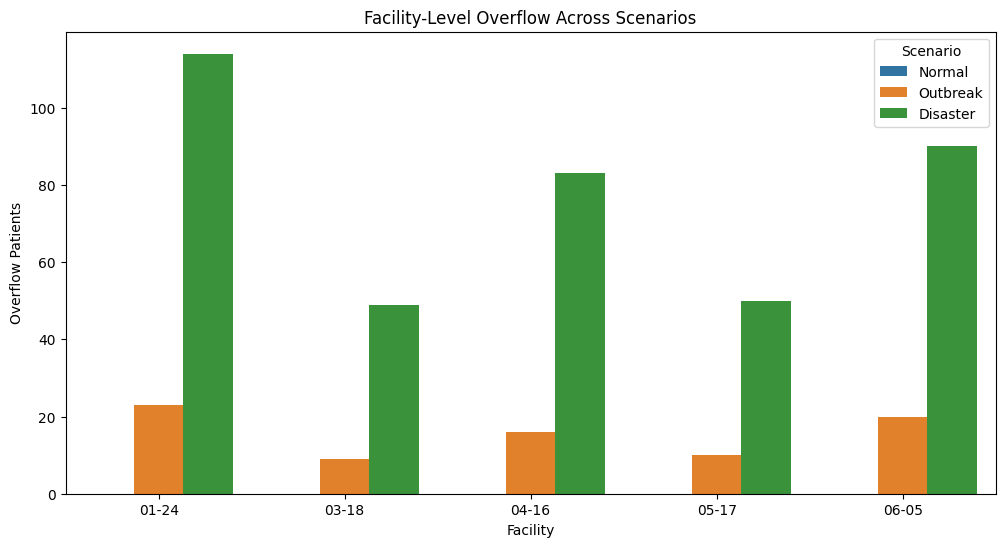

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_results(combined_results):
    # Facility-level overflow comparison
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=combined_results[combined_results["Layer"]=="Facility"],
        x="Facility_ID", y="Overflow", hue="Scenario"
    )
    plt.title("Facility-Level Overflow Across Scenarios")
    plt.ylabel("Overflow Patients")
    plt.xlabel("Facility")
    plt.legend(title="Scenario")
    plt.show()

visualize_results(combined_results)



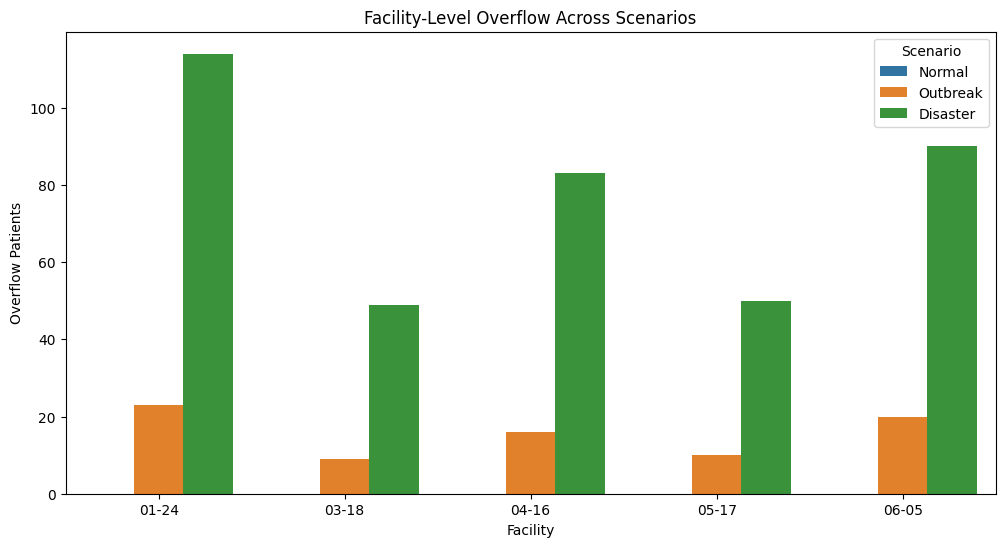

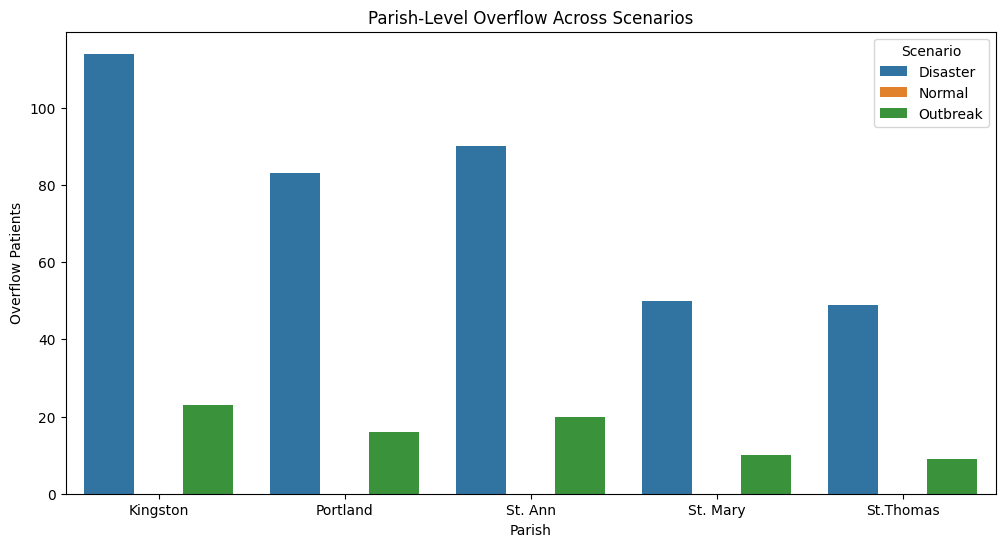

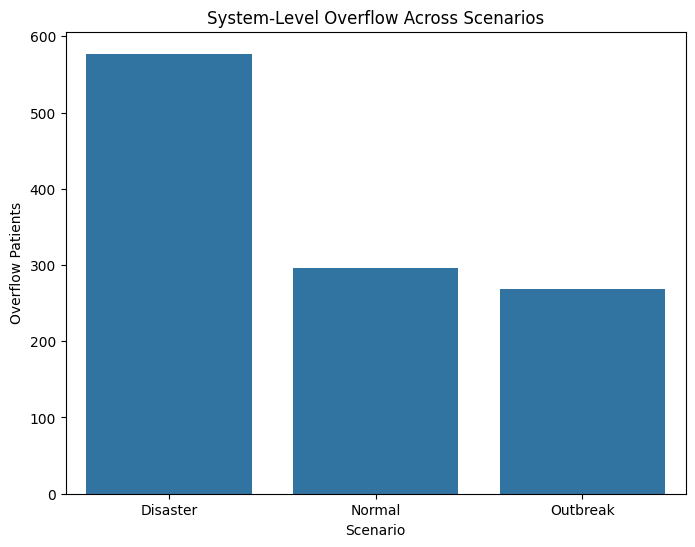

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_results(combined_results):
    # Facility-level overflow
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=combined_results[combined_results["Layer"]=="Facility"],
        x="Facility_ID", y="Overflow", hue="Scenario"
    )
    plt.title("Facility-Level Overflow Across Scenarios")
    plt.ylabel("Overflow Patients")
    plt.xlabel("Facility")
    plt.legend(title="Scenario")
    plt.show()

    # Parish-level overflow
    plt.figure(figsize=(12,6))
    parish_overflow = combined_results[combined_results["Layer"]=="Parish"].groupby(
        ["Parish","Scenario"], as_index=False)["Overflow"].sum()
    sns.barplot(data=parish_overflow, x="Parish", y="Overflow", hue="Scenario")
    plt.title("Parish-Level Overflow Across Scenarios")
    plt.ylabel("Overflow Patients")
    plt.xlabel("Parish")
    plt.legend(title="Scenario")
    plt.show()

    # System-level overflow
    plt.figure(figsize=(8,6))
    system_overflow = combined_results[combined_results["Layer"]=="System"].groupby(
        ["Scenario"], as_index=False)["Overflow"].sum()
    sns.barplot(data=system_overflow, x="Scenario", y="Overflow")
    plt.title("System-Level Overflow Across Scenarios")
    plt.ylabel("Overflow Patients")
    plt.xlabel("Scenario")
    plt.show()


visualize_results(combined_results)

In [ ]:
#This part of the code is for stress testing and scenario analysis, which is used to evaluate the performance of the optimization under different demand scenarios. The code includes defining additional demand scenarios (e.g., outbreak, disaster), running the optimization for each scenario, and visualizing the results to compare the overflow across scenarios and layers.

normal_demand = dict(zip(forecast_test_df["Facility_ID"], forecast_test_df["yhat"]))

scenarios = {
    "Normal": normal_demand,
    "Outbreak": {f: int(d * 1.3) for f, d in normal_demand.items()},
    "Disaster": {f: int(d * 1.5) for f, d in normal_demand.items()},
    "FluSeason": {f: int(d * 1.1) for f, d in normal_demand.items()},  # seasonal spike
    "PolicyReserve20": {f: d for f, d in normal_demand.items()}        # will enforce 20% reserve in system optimization
}

# In system_optimization, adjust reserve dynamically:
def system_optimization(demand_dict, beds_dict, df, reserve=0.1):
    system_capacity = df["Beds"].sum()
    system_demand = sum(demand_dict.values())

    prob = pulp.LpProblem("System_Optimization", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("assign", demand_dict.keys(), lowBound=0)

    prob += pulp.lpSum((demand_dict[f] - x[f]) for f in demand_dict.keys())

    for f in demand_dict.keys():
        prob += x[f] <= beds_dict[f]

    prob += pulp.lpSum(x[f] for f in demand_dict.keys()) <= system_capacity * (1 - reserve)
    prob += pulp.lpSum(x[f] for f in demand_dict.keys()) <= system_demand

    prob.solve()

    return pd.DataFrame([
        {"Facility_ID": f,
         "Demand": demand_dict[f],
         "Beds": beds_dict[f],
         "Assigned": x[f].varValue,
         "Overflow": max(0, demand_dict[f] - x[f].varValue)}
        for f in demand_dict.keys()
    ])